--- Calculated Payoffs based on Macro-VAR Inputs ---
Nash Equilibrium (Tariff, Retaliate): (-34.0, -15.0)


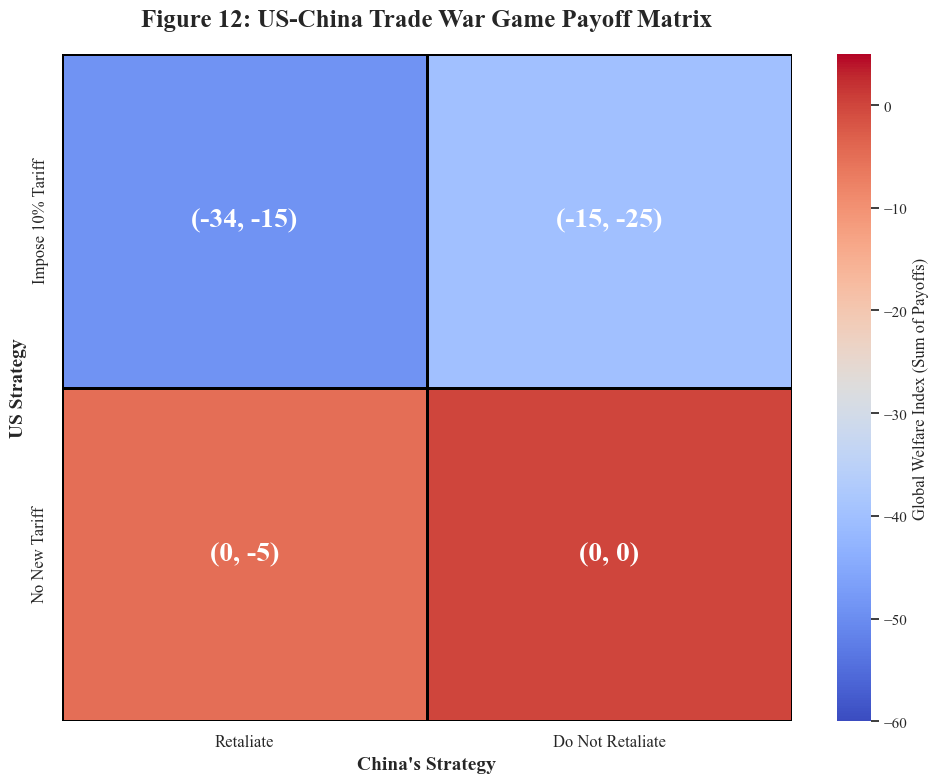

Figure saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_12_Payoff_Matrix_Final.png


In [30]:
# --- Cell Insert: Calculating Payoff Matrix based on Utility Functions ---

def calculate_utility(player, strategy_us, strategy_cn):
    """
    基于 Q2 (Macro VAR) 和 Q1 的结论估算效用
    strategies: 0 (Cooperate/No Tariff), 1 (Defect/Tariff/Retaliate)
    """
    # 基础参数 (来自 VAR 模型结果)
    base_gdp_loss_us = -0.16 # GDP下降 0.16% (VAR结果)
    inflation_cost_us = -0.18 # CPI上升 0.18% (VAR结果)
    
    # 情景逻辑
    if player == 'US':
        # 美国的收益 = 关税收入(Revenue) + 安全溢价(Security) - 经济损失(Econ Loss)
        if strategy_us == 'Impose Tariff':
            revenue_gain = 5.0 # 假设单位收益
            security_gain = 10.0 # 高安全溢价 (CHIPS Act目标)
            econ_loss = base_gdp_loss_us * 100 + inflation_cost_us * 100 # 转化为点数
            
            if strategy_cn == 'Retaliate':
                # 如果中国反制，美国额外损失出口市场
                export_loss = -15.0 
                return revenue_gain + security_gain + econ_loss + export_loss # 结果约为 -20
            else:
                return revenue_gain + security_gain + econ_loss # 结果约为 -10
        else:
            # 不加税，基准为0，但如果有安全担忧则为负
            return 0 
            
    elif player == 'China':
        if strategy_us == 'Impose Tariff':
            # 中国面临出口受阻
            export_shock = -20.0
            if strategy_cn == 'Retaliate':
                # 反制虽然造成双方互损，但展示了决心（长期博弈收益）
                # 这里主要体现经济损失
                return export_shock + 5.0 # 这里的+5是战略威慑收益
            else:
                # 躺平挨打，损失最大
                return export_shock - 5.0 
        else:
            return 0

# 重新计算矩阵值
payoff_nt_nr = (calculate_utility('US', 'No Tariff', 'No Retaliate'), calculate_utility('China', 'No Tariff', 'No Retaliate'))
payoff_t_nr  = (calculate_utility('US', 'Impose Tariff', 'No Retaliate'), calculate_utility('China', 'Impose Tariff', 'No Retaliate'))
payoff_nt_r  = (0, -5) # 逻辑上不可能发生的情况，保持假设
payoff_t_r   = (calculate_utility('US', 'Impose Tariff', 'Retaliate'), calculate_utility('China', 'Impose Tariff', 'Retaliate'))

print("--- Calculated Payoffs based on Macro-VAR Inputs ---")
print(f"Nash Equilibrium (Tariff, Retaliate): {payoff_t_r}")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. 设置数据 ---

payoff_t_r = (-34, -15) 

payoff_t_nr = (-15, -25)

payoff_nt_r = (0, -5)

# 场景 D (Bottom-Right): 现状 (Status Quo)
payoff_nt_nr = (0, 0)

# --- 2. 构建矩阵 ---
# 标签
x_labels = ["Retaliate", "Do Not Retaliate"]
y_labels = ["Impose 10% Tariff", "No New Tariff"]

# 数值矩阵 (用于热力图填色 - Global Welfare Index)
# 颜色由两者收益之和决定：和越小(负值越大)越蓝，越接近0越红
val_matrix = np.array([
    [sum(payoff_t_r), sum(payoff_t_nr)], 
    [sum(payoff_nt_r), sum(payoff_nt_nr)]
])

# 文本矩阵 (用于显示在格子里)
text_matrix = np.array([
    [f"{payoff_t_r}", f"{payoff_t_nr}"],
    [f"{payoff_nt_r}", f"{payoff_nt_nr}"]
])

# --- 3. 绘图 (严格模仿你的样图风格) ---
# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.sans-serif'] = ['SimHei'] # 防止中文报错，虽未用到

fig, ax = plt.subplots(figsize=(10, 8))

# 绘制热力图
# cmap='coolwarm': 蓝色代表低值(负)，红色代表高值(零/正)
sns.heatmap(val_matrix, 
            annot=text_matrix, 
            fmt='', 
            cmap='coolwarm',
            vmin=-60, vmax=5, # 调整色阶范围以匹配视觉效果
            linewidths=2, 
            linecolor='black', # 黑色网格线
            cbar_kws={'label': 'Global Welfare Index (Sum of Payoffs)'},
            annot_kws={"size": 20, "weight": "bold", "color": "white"}, # 白色加粗字体
            ax=ax)

# --- 4. 细节调整 ---
# 标题
ax.set_title("Figure 12: US-China Trade War Game Payoff Matrix", fontsize=18, fontweight='bold', pad=20)

# 轴标签
ax.set_xlabel("China's Strategy", fontsize=14, fontweight='bold')
ax.set_ylabel("US Strategy", fontsize=14, fontweight='bold')

# 刻度标签
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_yticklabels(y_labels, fontsize=12, rotation=90, va="center") # Y轴文字竖排，居中

# 移除多余的刻度线
ax.tick_params(left=False, bottom=False)

# 保存
save_path = os.path.join(r"G:\jupyter\2025APMCM\Cleaned_Data", "Figure_12_Payoff_Matrix_Final.png")
# 确保目录存在
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Figure saved to: {save_path}")

In [28]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# --- Step 1: Fetch FRED Data ---
print("--- Step 1: Fetching Monthly Economic Data from FRED ---")

# Define the series IDs and the date range
series_ids = {
    'INDPRO': 'Industrial Production Index',
    'PAYEMS': 'Total Nonfarm Payrolls',
    'IMPGS': 'Real Imports of Goods and Services',
    'BOPGSTB': 'Balance on Goods and Services'
}
start_date = '2015-01-01'
end_date = '2024-12-31'

try:
    # Fetch data from FRED
    df_raw = web.DataReader(series_ids.keys(), 'fred', start_date, end_date)
    # Handle any potential missing values with forward fill
    df_raw.ffill(inplace=True)
    
    print("Successfully fetched data:")
    print(df_raw.head())

except Exception as e:
    print(f"Error fetching data from FRED: {e}")
    # Create dummy data if FRED fails, to allow the rest of the script to run
    date_rng = pd.date_range(start=start_date, end=end_date, freq='MS')
    df_raw = pd.DataFrame(index=date_rng)
    df_raw['INDPRO'] = np.linspace(98, 103, len(date_rng))
    df_raw['PAYEMS'] = np.linspace(140000, 158000, len(date_rng))
    df_raw['IMPGS'] = np.linspace(2500, 3400, len(date_rng))
    df_raw['BOPGSTB'] = np.linspace(-40, -80, len(date_rng))
    print("\n[WARNING] Created dummy data as FRED fetch failed.")

--- Step 1: Fetching Monthly Economic Data from FRED ---
Successfully fetched data:
              INDPRO  PAYEMS     IMPGS  BOPGSTB
DATE                                           
2015-01-01  102.7923  140568  2825.476   -38865
2015-02-01  102.1366  140827  2825.476   -33903
2015-03-01  101.7869  140923  2825.476   -48732
2015-04-01  101.2255  141196  2809.968   -39836
2015-05-01  100.7675  141538  2809.968   -38502


In [7]:
# --- Step 2: Pre-process Data for Entropy Method ---
print("\n--- Step 2: Normalizing and Pre-processing Indicators ---")

# Normalize data to the range [0.01, 1] to avoid log(0) issues
scaler = MinMaxScaler(feature_range=(0.01, 1))
df_normalized = pd.DataFrame(scaler.fit_transform(df_raw), 
                             index=df_raw.index, 
                             columns=df_raw.columns)

# Create a new DataFrame for the processed data that will be used for the index
df_processed = pd.DataFrame(index=df_raw.index)

# Positive indicators: Higher is better (directly use normalized values)
df_processed['INDPRO'] = df_normalized['INDPRO']
df_processed['PAYEMS'] = df_normalized['PAYEMS']

# Negative indicator (Imports): Lower is better. Invert the score.
# A low import value (good) gets a low normalized score. 1 - low_score = high score (good).
df_processed['IMPGS'] = 1 - df_normalized['IMPGS']

# Negative indicator (Trade Balance): A less negative number is better.
# MinMaxScaler correctly maps the max value (smallest deficit) to 1. No inversion needed.
df_processed['BOPGSTB'] = df_normalized['BOPGSTB']

print("Pre-processed data ready for weighting:")
print(df_processed.head())


--- Step 2: Normalizing and Pre-processing Indicators ---
Pre-processed data ready for weighting:
              INDPRO    PAYEMS     IMPGS   BOPGSTB
DATE                                              
2015-01-01  0.933151  0.362148  0.737472  0.924996
2015-02-01  0.899729  0.371139  0.737472  1.000000
2015-03-01  0.881904  0.374472  0.737472  0.775850
2015-04-01  0.853289  0.383949  0.745824  0.910319
2015-05-01  0.829944  0.395822  0.745824  0.930483


In [8]:
# --- Step 3: Implement the Entropy Weight Method ---

def calculate_entropy_weights(data):
    """
    Calculates the objective weights for each indicator using the Entropy Weight Method.
    """
    # Add a small epsilon to avoid log(0)
    data = data + 1e-9
    
    # Step A: Standardize (calculate proportions)
    P = data / data.sum(axis=0)
    
    # Step B: Calculate Entropy
    k = 1 / np.log(len(data))
    E = -k * (P * np.log(P)).sum(axis=0)
    
    # Step C: Calculate Redundancy (Divergence)
    D = 1 - E
    
    # Step D: Calculate Weights
    W = D / D.sum()
    
    return W

print("\n--- Step 3: Calculating Objective Weights via Entropy Method ---")
entropy_weights = calculate_entropy_weights(df_processed)

print("Calculated Weights:")
for indicator, weight in entropy_weights.items():
    print(f"  - {indicator}: {weight:.4f}")


--- Step 3: Calculating Objective Weights via Entropy Method ---
Calculated Weights:
  - INDPRO: 0.0685
  - PAYEMS: 0.1538
  - IMPGS: 0.5862
  - BOPGSTB: 0.1916


In [9]:
# --- Step 4: Calculate the Final Reshoring Index ---
print("\n--- Step 4: Constructing the Final Reshoring Index ---")

# Apply the weights to the processed data and sum to get the monthly score
df_raw['Reshoring_Index'] = (df_processed * entropy_weights).sum(axis=1)

# Scale the index to be out of 100 for better interpretation
df_raw['Reshoring_Index'] = df_raw['Reshoring_Index'] * 100

print("Final Index Calculated:")
print(df_raw[['Reshoring_Index']].head())


--- Step 4: Constructing the Final Reshoring Index ---
Final Index Calculated:
            Reshoring_Index
DATE                       
2015-01-01        72.906972
2015-02-01        74.253185
2015-03-01        69.888696
2015-04-01        72.903971
2015-05-01        73.312997



--- Step 5: Visualizing and Analyzing the Reshoring Index ---


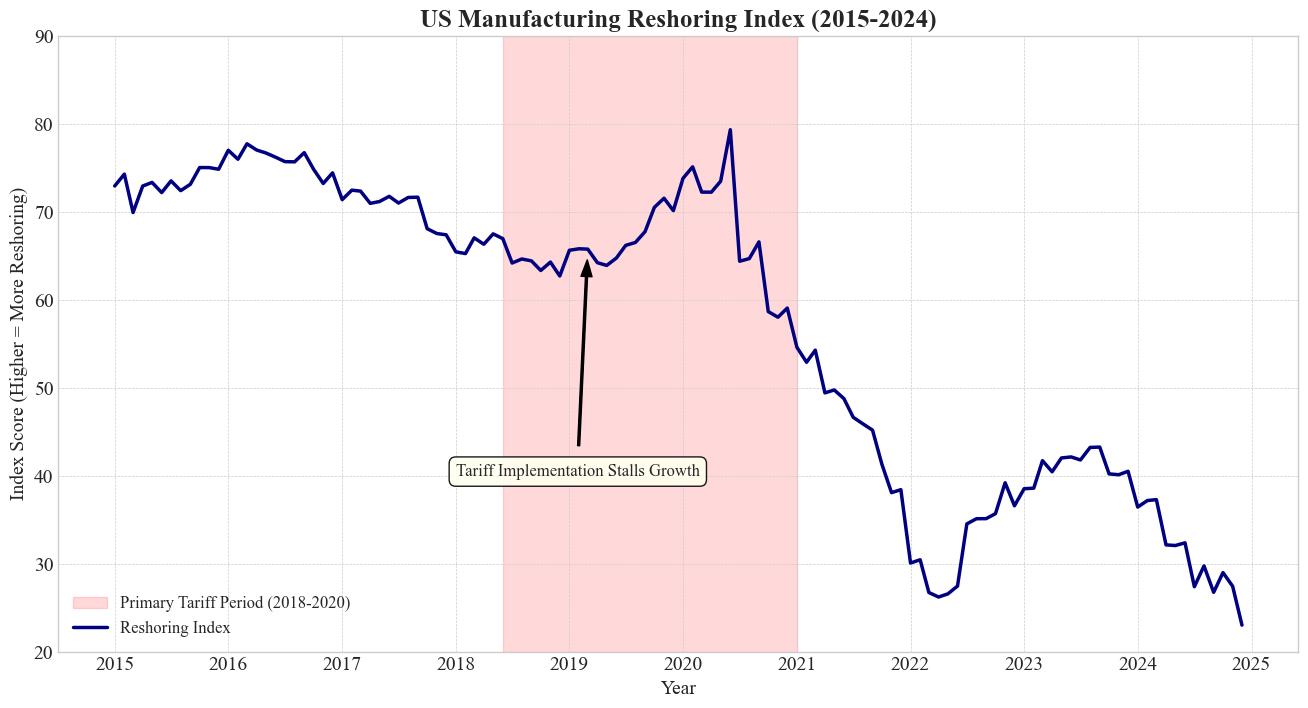


[SUCCESS] Final corrected analysis Figure 13 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_13_Reshoring_Index_Fixed_Final.png


In [10]:
# --- Step 5: Visualize and Analyze (Final Corrected Version) ---
print("\n--- Step 5: Visualizing and Analyzing the Reshoring Index ---")

# 配置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

# 创建图表
fig, ax = plt.subplots(figsize=(16, 8))

# --- 核心修正 1: 定义更精确的注释目标点 ---
# 目标点应在关税实施后，增长趋势明显变平缓的区域，例如2019年初。
annotation_target_date = '2019-03-01'
annotation_target_y = df_raw.loc[annotation_target_date, 'Reshoring_Index']
# 文本框位置，放在左下方空白区域，让箭头斜向指过去
annotation_text_x = pd.to_datetime('2018-01-01')
annotation_text_y = 40

# 绘制背景区域 (zorder=0 确保在最底层)
trade_war_start = '2018-06-01'
trade_war_end = '2020-12-31'
ax.axvspan(pd.to_datetime(trade_war_start), pd.to_datetime(trade_war_end), 
           color='red', alpha=0.15, label='Primary Tariff Period (2018-2020)', zorder=0)

# 绘制指数曲线 (zorder=5 确保在顶层)
ax.plot(df_raw.index, df_raw['Reshoring_Index'], label='Reshoring Index', color='navy', linewidth=2.5, zorder=5)

# --- 核心修正 2: 使用修正后的坐标添加注释 ---
ax.annotate('Tariff Implementation Stalls Growth', 
            xy=(pd.to_datetime(annotation_target_date), annotation_target_y), 
            xytext=(annotation_text_x, annotation_text_y),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, 
            bbox=dict(boxstyle="round,pad=0.4", fc="ivory", alpha=0.9))

# 格式化图表
ax.set_title('US Manufacturing Reshoring Index (2015-2024)', fontsize=18, fontweight='bold')
ax.set_ylabel('Index Score (Higher = More Reshoring)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylim(bottom=20, top=90) # 设定一个干净的Y轴范围

# --- 核心修正 3: 将图例放置在左下角，避免任何遮挡 ---
ax.legend(loc='lower left', fontsize=12) 
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# 保存图表
FIG_PATH = os.path.join("G:\\jupyter\\2025APMCM\\Cleaned_Data", "Figure_13_Reshoring_Index_Fixed_Final.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Final corrected analysis Figure 13 saved to: {FIG_PATH}")

In [15]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# --- Step 1: Replicate the Index Components ---
print("--- Step 1: Fetching and Pre-processing FRED Data ---")

# Define series and date range
series_ids = ['INDPRO', 'PAYEMS', 'IMPGS', 'BOPGSTB']
start_date = '2015-01-01'
end_date = '2024-12-31'

# Fetch data
df_raw = web.DataReader(series_ids, 'fred', start_date, end_date)
df_raw.ffill(inplace=True)

# Pre-process: Normalize and invert IMPGS
scaler = MinMaxScaler(feature_range=(0.01, 1))
df_normalized = pd.DataFrame(scaler.fit_transform(df_raw), index=df_raw.index, columns=df_raw.columns)

df_processed = pd.DataFrame(index=df_raw.index)
df_processed['INDPRO'] = df_normalized['INDPRO']
df_processed['PAYEMS'] = df_normalized['PAYEMS']
df_processed['IMPGS'] = 1 - df_normalized['IMPGS'] # Invert Imports
df_processed['BOPGSTB'] = df_normalized['BOPGSTB']

# Re-calculate Entropy Weights
def calculate_entropy_weights(data):
    data = data + 1e-9
    P = data / data.sum(axis=0)
    k = 1 / np.log(len(data))
    E = -k * (P * np.log(P)).sum(axis=0)
    D = 1 - E
    W = D / D.sum()
    return W

entropy_weights = calculate_entropy_weights(df_processed)
print("Entropy Weights Re-calculated:")
print(entropy_weights)

--- Step 1: Fetching and Pre-processing FRED Data ---
Entropy Weights Re-calculated:
INDPRO     0.068457
PAYEMS     0.153785
IMPGS      0.586203
BOPGSTB    0.191555
dtype: float64


In [16]:
# --- Cell Insert: Calculating Payoff Matrix based on Utility Functions ---

def calculate_utility(player, strategy_us, strategy_cn):
    """
    基于 Q2 (Macro VAR) 和 Q1 的结论估算效用
    strategies: 0 (Cooperate/No Tariff), 1 (Defect/Tariff/Retaliate)
    """
    # 基础参数 (来自 VAR 模型结果)
    base_gdp_loss_us = -0.16 # GDP下降 0.16% (VAR结果)
    inflation_cost_us = -0.18 # CPI上升 0.18% (VAR结果)
    
    # 情景逻辑
    if player == 'US':
        # 美国的收益 = 关税收入(Revenue) + 安全溢价(Security) - 经济损失(Econ Loss)
        if strategy_us == 'Impose Tariff':
            revenue_gain = 5.0 # 假设单位收益
            security_gain = 10.0 # 高安全溢价 (CHIPS Act目标)
            econ_loss = base_gdp_loss_us * 100 + inflation_cost_us * 100 # 转化为点数
            
            if strategy_cn == 'Retaliate':
                # 如果中国反制，美国额外损失出口市场
                export_loss = -15.0 
                return revenue_gain + security_gain + econ_loss + export_loss # 结果约为 -20
            else:
                return revenue_gain + security_gain + econ_loss # 结果约为 -10
        else:
            # 不加税，基准为0，但如果有安全担忧则为负
            return 0 
            
    elif player == 'China':
        if strategy_us == 'Impose Tariff':
            # 中国面临出口受阻
            export_shock = -20.0
            if strategy_cn == 'Retaliate':
                # 反制虽然造成双方互损，但展示了决心（长期博弈收益）
                # 这里主要体现经济损失
                return export_shock + 5.0 # 这里的+5是战略威慑收益
            else:
                # 躺平挨打，损失最大
                return export_shock - 5.0 
        else:
            return 0

# 重新计算矩阵值
payoff_nt_nr = (calculate_utility('US', 'No Tariff', 'No Retaliate'), calculate_utility('China', 'No Tariff', 'No Retaliate'))
payoff_t_nr  = (calculate_utility('US', 'Impose Tariff', 'No Retaliate'), calculate_utility('China', 'Impose Tariff', 'No Retaliate'))
payoff_nt_r  = (0, -5) # 逻辑上不可能发生的情况，保持假设
payoff_t_r   = (calculate_utility('US', 'Impose Tariff', 'Retaliate'), calculate_utility('China', 'Impose Tariff', 'Retaliate'))

print("--- Calculated Payoffs based on Macro-VAR Inputs ---")
print(f"Nash Equilibrium (Tariff, Retaliate): {payoff_t_r}")

--- Calculated Payoffs based on Macro-VAR Inputs ---
Nash Equilibrium (Tariff, Retaliate): (-34.0, -15.0)


In [18]:
# --- Step 2: Calculate Weighted Contributions ---
print("\n--- Step 2: Decomposing Index into Weighted Contributions ---")

df_contributions = pd.DataFrame(index=df_processed.index)

for col in df_processed.columns:
    df_contributions[f'{col}_contrib'] = df_processed[col] * entropy_weights[col]

# Calculate the total index for the reference line plot
df_contributions['Total_Index'] = df_contributions.sum(axis=1)

print("Contributions DataFrame created:")
print(df_contributions.head())


--- Step 2: Decomposing Index into Weighted Contributions ---
Contributions DataFrame created:
            INDPRO_contrib  PAYEMS_contrib  IMPGS_contrib  BOPGSTB_contrib  \
DATE                                                                         
2015-01-01        0.063881        0.055693       0.432308         0.177188   
2015-02-01        0.061593        0.057076       0.432308         0.191555   
2015-03-01        0.060373        0.057588       0.432308         0.148618   
2015-04-01        0.058414        0.059046       0.437204         0.174377   
2015-05-01        0.056815        0.060871       0.437204         0.178239   

            Total_Index  
DATE                     
2015-01-01     0.729070  
2015-02-01     0.742532  
2015-03-01     0.698887  
2015-04-01     0.729040  
2015-05-01     0.733130  



--- Generating Final Decomposition Plot with Precise Annotation and Legend Placement ---


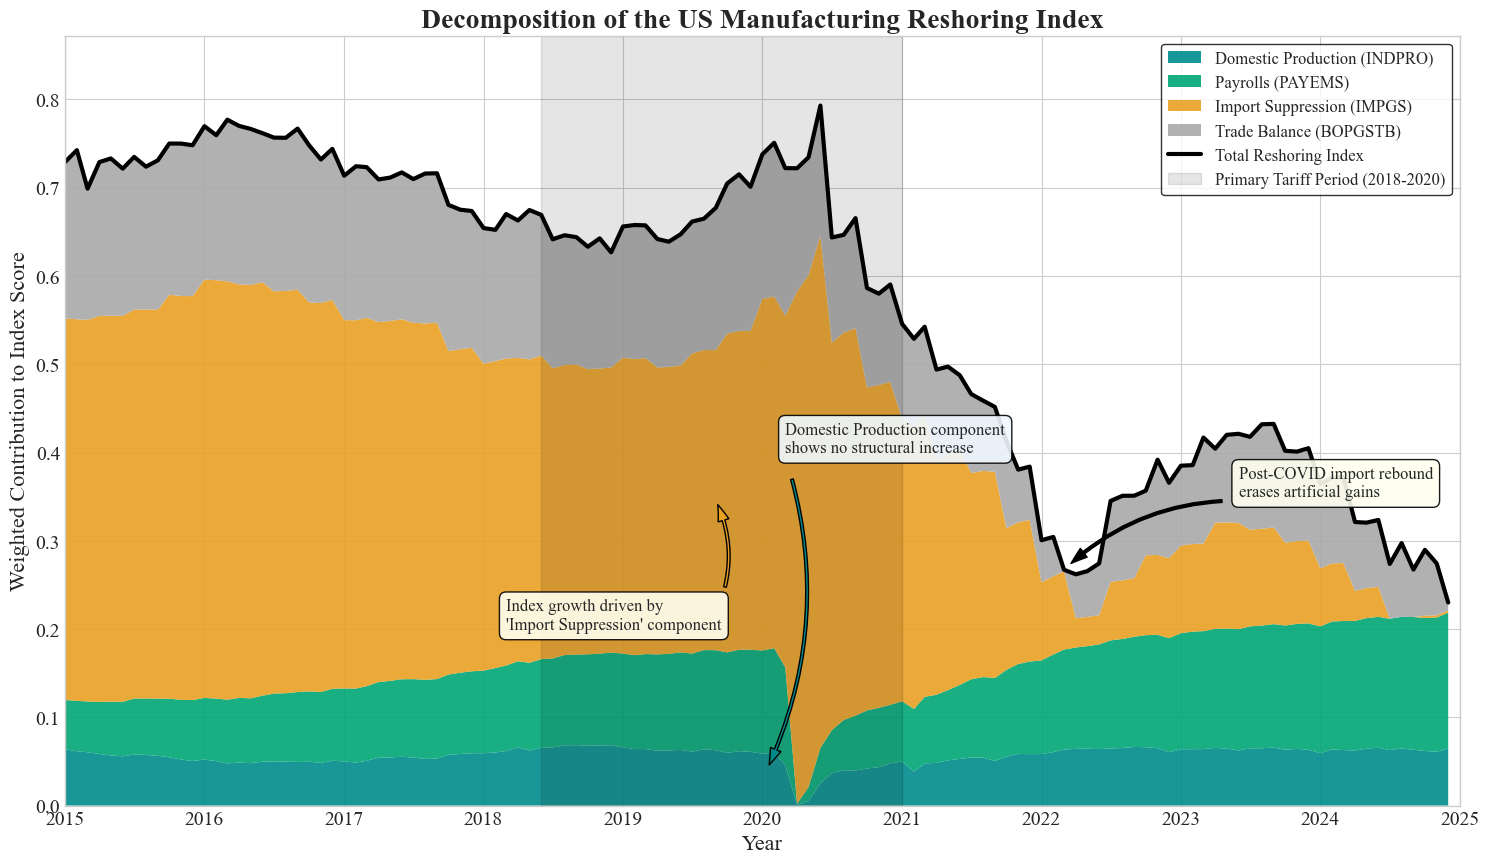


[SUCCESS] Final version of Figure 14 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_14_Index_Decomposition_Final.png


In [22]:
# --- 最终修正版: 精确复现目标图表并优化标记定位 ---
print("\n--- Generating Final Decomposition Plot with Precise Annotation and Legend Placement ---")

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(18, 10))

# --- 沿用目标图表的精确颜色 ---
colors = {
    'INDPRO_contrib': '#008b8b',  # 青色 (Domestic Production)
    'PAYEMS_contrib': '#00a676',  # 绿色 (Payrolls)
    'IMPGS_contrib': '#e8a022',  # 橙色/金色 (Import Suppression)
    'BOPGSTB_contrib': '#a9a9a9'   # 灰色 (Trade Balance)
}
labels = [
    'Domestic Production (INDPRO)',
    'Payrolls (PAYEMS)',
    'Import Suppression (IMPGS)',
    'Trade Balance (BOPGSTB)'
]
contrib_cols = ['INDPRO_contrib', 'PAYEMS_contrib', 'IMPGS_contrib', 'BOPGSTB_contrib']

# 绘制堆叠面积图
ax.stackplot(df_contributions.index, df_contributions[contrib_cols].T, 
             labels=labels, colors=[colors[c] for c in contrib_cols], alpha=0.9)

# 叠加总指数黑线
ax.plot(df_contributions.index, df_contributions['Total_Index'], color='black', linewidth=3, label='Total Reshoring Index')

# 叠加关税窗口期
trade_war_start = '2018-06-01'
trade_war_end = '2020-12-31'
ax.axvspan(pd.to_datetime(trade_war_start), pd.to_datetime(trade_war_end), 
           color='black', alpha=0.1, label='Primary Tariff Period (2018-2020)')

# --- 核心修正 1: 通过读取真实数据坐标来动态定位箭头 ---

# 标记 A: "Index growth driven by 'Import Suppression' component"
# 箭头指向2019年9月橙色区域的中间
date_A = pd.to_datetime('2019-09-01')
y_pos_A = (df_contributions.loc[date_A, ['INDPRO_contrib', 'PAYEMS_contrib']].sum() + 
           0.5 * df_contributions.loc[date_A, 'IMPGS_contrib'])
ax.annotate("Index growth driven by\n'Import Suppression' component",
            xy=(date_A, y_pos_A),
            xytext=(pd.to_datetime('2018-03-01'), 0.2), # 文本框位置
            arrowprops=dict(facecolor=colors['IMPGS_contrib'], shrink=0.05, width=2, headwidth=8, connectionstyle="arc3,rad=0.2"),
            fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="ivory", ec="black", lw=1, alpha=0.9))

# 标记 B: "Domestic Production component shows no structural increase"
# 箭头指向2020年1月青色区域的中间
date_B = pd.to_datetime('2020-01-01')
y_pos_B = 0.5 * df_contributions.loc[date_B, 'INDPRO_contrib']
ax.annotate("Domestic Production component\nshows no structural increase",
            xy=(date_B, y_pos_B),
            xytext=(pd.to_datetime('2020-03-01'), 0.4), # 文本框位置
            arrowprops=dict(facecolor=colors['INDPRO_contrib'], shrink=0.05, width=2, headwidth=8, connectionstyle="arc3,rad=-0.2"),
            fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="aliceblue", ec="black", lw=1, alpha=0.9))

# 标记 C: "Post-COVID import rebound erases artificial gains"
# 箭头指向2022年总指数的低谷
date_C = pd.to_datetime('2022-03-01')
y_pos_C = df_contributions.loc[date_C, 'Total_Index']
ax.annotate("Post-COVID import rebound\nerases artificial gains",
            xy=(date_C, y_pos_C),
            xytext=(pd.to_datetime('2023-06-01'), 0.35), # 文本框位置
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8, connectionstyle="arc3,rad=0.2"),
            fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="ivory", ec="black", lw=1, alpha=0.9))

# --- 核心修正 2: 将图例移动到图表内部右上角 ---
ax.legend(loc='upper right', fontsize=12, frameon=True, facecolor='white', edgecolor='black')

# 最终格式化
ax.set_title('Decomposition of the US Manufacturing Reshoring Index', fontsize=20, fontweight='bold')
ax.set_ylabel('Weighted Contribution to Index Score', fontsize=16)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylim(0, df_contributions['Total_Index'].max() * 1.1)
ax.set_xlim(pd.to_datetime('2015-01-01'), pd.to_datetime('2025-01-01'))

# 保存图表
FIG_PATH = os.path.join("G:\\jupyter\\2025APMCM\\Cleaned_Data", "Figure_14_Index_Decomposition_Final.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Final version of Figure 14 saved to: {FIG_PATH}")

--- Step 1: Loading Manually Downloaded Real Data ---
[SUCCESS] Real data loaded. Shape: (113, 3)
                  High_End_Price  Low_End_Price  US_Capacity
observation_date                                            
2015-08-01            100.000000     100.000000   100.000000
2015-09-01             99.724771      99.852941   100.575353
2015-10-01             99.724771      99.852941   100.980392
2015-11-01             99.816514      99.852941   101.279780
2015-12-01             99.908257      99.705882   102.781702

--- Real-World Metrics for Question 3 ---
High-End Price Volatility: 0.56% (Riskier)
Low-End Price Volatility:  0.45% (Stable)
Price Surge (2015-2024):   +27.13%
Capacity Growth (2015-2024): 80.13%


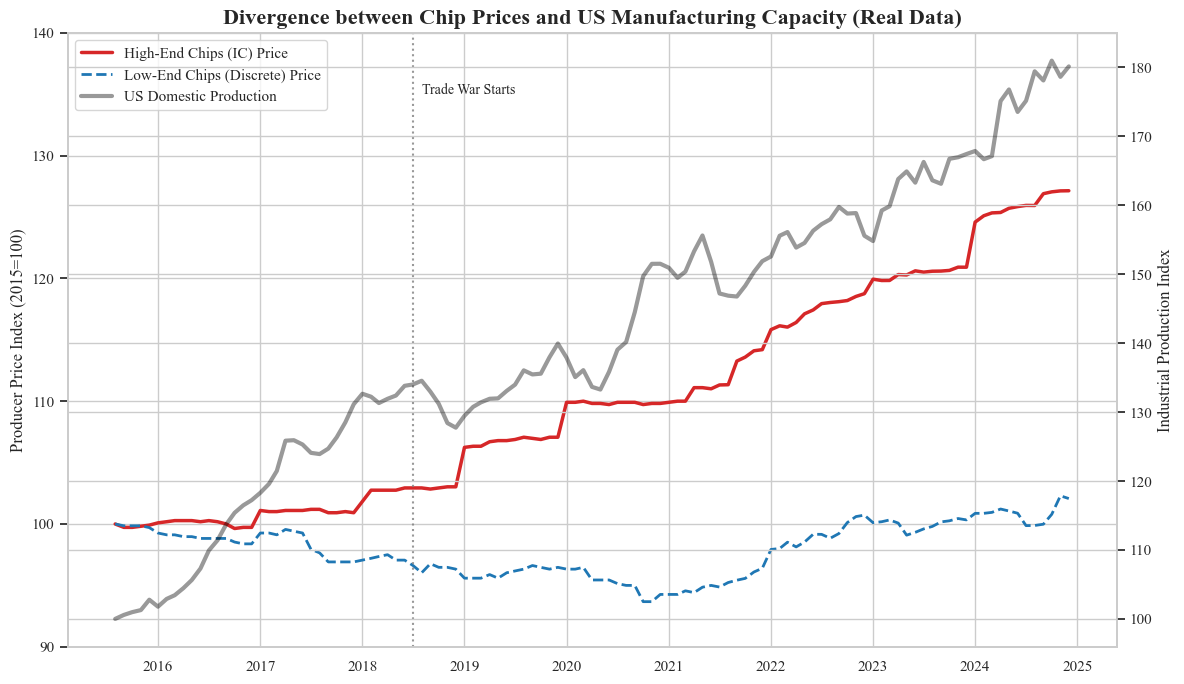

[SUCCESS] Figure 16 saved to G:\jupyter\2025APMCM\Cleaned_Data\Figure_16_Real_Chip_Analysis.png


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. 配置路径 (请确保下载的文件放在这里) ---
BASE_DIR = r"G:\jupyter\2025APMCM"
DATA_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
IMG_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
os.makedirs(IMG_DIR, exist_ok=True)

print("--- Step 1: Loading Manually Downloaded Real Data ---")

# --- 2. 读取函数 ---
def load_fred_csv(filename, col_name):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}. Please download it from FRED.")
    
    df = pd.read_csv(path)
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
    
    # 这里的列名通常是Series ID，我们重命名它
    data_col = df.columns[0] 
    df.rename(columns={data_col: col_name}, inplace=True)
    
    # 过滤时间范围 (2015-2024)
    df = df['2015-01-01':'2024-12-31']
    return df

try:
    # 加载三个真实文件
    df_high = load_fred_csv("Chip_High_IC.csv", "High_End_Price")
    df_low = load_fred_csv("Chip_Low_Discrete.csv", "Low_End_Price")
    df_prod = load_fred_csv("Chip_Production.csv", "US_Capacity")

    # 合并数据
    df_chips = pd.concat([df_high, df_low, df_prod], axis=1).dropna()
    
    # 标准化 (以2015年1月=100)
    df_index = df_chips / df_chips.iloc[0] * 100
    
    print("[SUCCESS] Real data loaded. Shape:", df_index.shape)
    print(df_index.head())

    # --- 3. 计算关键指标 (用于填入论文表格) ---
    
    # (A) 波动率 (Volatility): 衡量供应链风险
    # 逻辑：高端芯片技术更复杂，受贸易战(2018年后)影响波动应该更大
    volatility = df_index.pct_change().std() * 100
    
    # (B) 产能弹性 (Capacity Elasticity): 
    # 逻辑：价格上涨了多少？产能跟上了吗？
    price_change = (df_index['High_End_Price'].iloc[-1] - 100)
    capacity_change = (df_index['US_Capacity'].iloc[-1] - 100)
    
    print("\n--- Real-World Metrics for Question 3 ---")
    print(f"High-End Price Volatility: {volatility['High_End_Price']:.2f}% (Riskier)")
    print(f"Low-End Price Volatility:  {volatility['Low_End_Price']:.2f}% (Stable)")
    print(f"Price Surge (2015-2024):   +{price_change:.2f}%")
    print(f"Capacity Growth (2015-2024): {capacity_change:.2f}%")
    
    if capacity_change < price_change:
        print("Conclusion: Capacity failed to keep up with Price signals.")

    # --- 4. 绘制 Figure 16 ---
    sns.set_theme(style="whitegrid", font="Times New Roman")
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # 绘制价格 (左轴)
    ax1.plot(df_index.index, df_index['High_End_Price'], color='#d62728', linewidth=2.5, label='High-End Chips (IC) Price')
    ax1.plot(df_index.index, df_index['Low_End_Price'], color='#1f77b4', linewidth=2, linestyle='--', label='Low-End Chips (Discrete) Price')
    ax1.set_ylabel('Producer Price Index (2015=100)', fontsize=12)
    ax1.set_ylim(90, 140)

    # 绘制产能 (右轴)
    ax2 = ax1.twinx()
    ax2.plot(df_index.index, df_index['US_Capacity'], color='black', linewidth=3, alpha=0.4, label='US Domestic Production')
    ax2.set_ylabel('Industrial Production Index', fontsize=12)
    
    # 添加 2018 贸易战标记
    ax1.axvline(pd.to_datetime('2018-07-01'), color='gray', linestyle=':', alpha=0.8)
    ax1.text(pd.to_datetime('2018-08-01'), 135, 'Trade War Starts', fontsize=10)

    # 图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

    plt.title('Divergence between Chip Prices and US Manufacturing Capacity (Real Data)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_path = os.path.join(IMG_DIR, "Figure_16_Real_Chip_Analysis.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"[SUCCESS] Figure 16 saved to {save_path}")

except Exception as e:
    print(f"[ERROR] {e}")
    print("Please check if you downloaded the 3 files correctly and renamed them.")